# 16. Unsupervised Clustering and Dimensionality Reduction

Clustering methods identify **natural groupings** in data without using class labels.
Combined with nonlinear dimensionality reduction (t-SNE, UMAP), they reveal structure
that linear PCA may miss.

**Topics covered**
1. K-Means clustering and the elbow / silhouette method
2. Hierarchical clustering and dendrograms
3. DBSCAN — density-based clustering for non-convex shapes
4. t-SNE — nonlinear dimensionality reduction for 2-D visualisation
5. UMAP — faster nonlinear embedding
6. Comparing cluster assignments with known steel grades


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import umap

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(99)


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 16.1 Dataset: XRF Elemental Analysis of Steel Grades

Same simulated XRF dataset as Notebook 12 (PCA, Part IV): 120 steel specimens across four grades, eight elements. Here we **ignore the grade labels** during clustering and ask whether the algorithm recovers them automatically.

In [2]:
elements = ['Fe', 'Cr', 'Ni', 'Mo', 'Mn', 'Si', 'Cu', 'N']

grade_comp = {
    '304SS':   {'Fe':71, 'Cr':18, 'Ni':8,  'Mo':0.2, 'Mn':1.5, 'Si':0.5, 'Cu':0.3, 'N':0.05},
    '316SS':   {'Fe':68, 'Cr':17, 'Ni':12, 'Mo':2.5, 'Mn':1.5, 'Si':0.5, 'Cu':0.3, 'N':0.05},
    '2205Dup': {'Fe':68, 'Cr':22, 'Ni':5,  'Mo':3.2, 'Mn':1.2, 'Si':0.4, 'Cu':0.2, 'N':0.17},
    '17-4PH':  {'Fe':75, 'Cr':16, 'Ni':4,  'Mo':0.3, 'Mn':0.5, 'Si':0.6, 'Cu':3.5, 'N':0.04},
}
sigma = {'Fe':0.5,'Cr':0.2,'Ni':0.2,'Mo':0.05,'Mn':0.1,'Si':0.05,'Cu':0.1,'N':0.01}

rows, true_labels = [], []
for grade, means in grade_comp.items():
    for _ in range(30):
        row = {el: rng.normal(means[el], sigma[el]) for el in elements}
        rows.append(row)
        true_labels.append(grade)

df = pd.DataFrame(rows)
grades = np.array(true_labels)
grade_list = list(grade_comp.keys())

scaler = StandardScaler()
X = scaler.fit_transform(df[elements].values)

print(f'Dataset: {X.shape[0]} samples × {X.shape[1]} features')
print(f'Grades: {grade_list}')


Dataset: 120 samples × 8 features
Grades: ['304SS', '316SS', '2205Dup', '17-4PH']


## 16.2 K-Means Clustering

K-Means starts by guessing $k$ cluster centres, assigns every sample to its
*nearest* centre, then moves each centre to the average position of the
samples now assigned to it — repeating this "assign, then re-average" cycle
until the centres stop moving. The result is $k$ groups chosen to make each
sample as close as possible to its own group's centre — formally, minimising
the total within-cluster sum of squared distances (inertia):

$$\text{Inertia} = \sum_{k=1}^K \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

The catch is that you must choose $k$ in advance, and K-Means will happily
produce *some* answer for any $k$ you give it — even a wrong one. The
**elbow method** and **silhouette score** below are two ways to check
whether a given $k$ actually fits the data well, rather than trusting the
algorithm's output blindly.

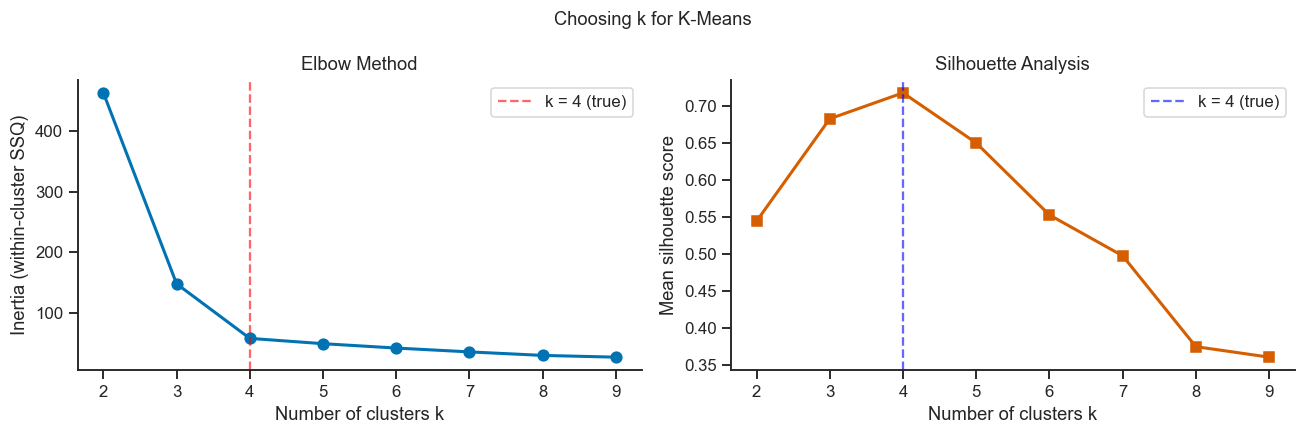

In [3]:
# ── Elbow and silhouette curves ───────────────────────────────────────────────
k_range = range(2, 10)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'bo-', lw=2, ms=7)
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (within-cluster SSQ)')
axes[0].set_title('Elbow Method')
axes[0].axvline(4, color='red', ls='--', alpha=0.6, label='k = 4 (true)')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].plot(list(k_range), silhouettes, 'rs-', lw=2, ms=7)
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Mean silhouette score')
axes[1].set_title('Silhouette Analysis')
axes[1].axvline(4, color='blue', ls='--', alpha=0.6, label='k = 4 (true)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle('Choosing k for K-Means', fontsize=12)
plt.tight_layout()
plt.show()


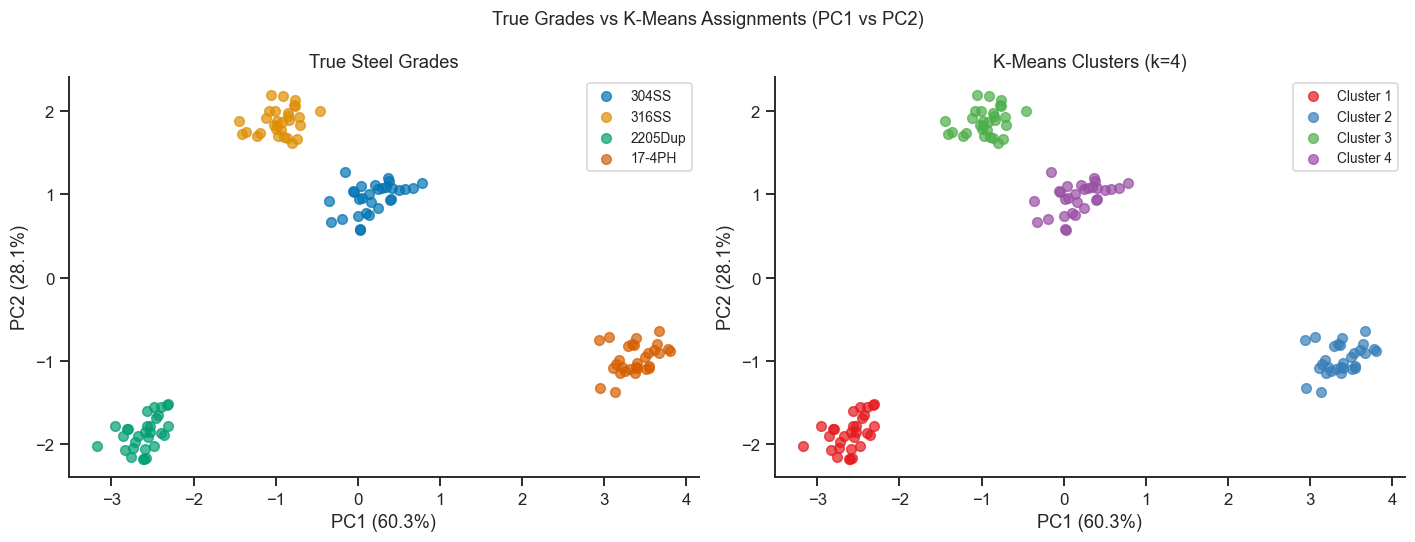

Adjusted Rand Index (vs true grades): 1.000  [1.0 = perfect]


In [4]:
# ── Fit K-Means with k = 4 ────────────────────────────────────────────────────
from sklearn.decomposition import PCA as SkPCA

km4 = KMeans(n_clusters=4, random_state=0, n_init=20)
km_labels = km4.fit_predict(X)

# Project to 2-D PCA for plotting
pca_2d = SkPCA(n_components=2)
Z = pca_2d.fit_transform(X)
ev = pca_2d.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_grade = sns.color_palette('colorblind', 4)
colors_km    = sns.color_palette('Set1', 4)

# True grades
ax = axes[0]
for gi, grade in enumerate(grade_list):
    mask = grades == grade
    ax.scatter(Z[mask,0], Z[mask,1], c=[colors_grade[gi]], label=grade, s=40, alpha=0.7)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('True Steel Grades')
ax.legend(fontsize=9)
sns.despine(ax=ax)

# K-Means clusters
ax = axes[1]
for ki in range(4):
    mask = km_labels == ki
    ax.scatter(Z[mask,0], Z[mask,1], c=[colors_km[ki]], label=f'Cluster {ki+1}', s=40, alpha=0.7)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('K-Means Clusters (k=4)')
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.suptitle('True Grades vs K-Means Assignments (PC1 vs PC2)', fontsize=12)
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(grades, km_labels)
print(f'Adjusted Rand Index (vs true grades): {ari:.3f}  [1.0 = perfect]')


### Interpreting K-Means Results

- The **elbow** in the inertia curve and the **peak silhouette score** both indicate k = 4, matching the true number of steel grades.
- The **Adjusted Rand Index (ARI)** measures agreement between K-Means clusters and true grade labels: ARI = 1 means perfect correspondence; ARI ≈ 0 means random agreement.
- In PCA space the K-Means assignment closely follows the true grade clusters, confirming that the eight XRF elements alone are sufficient to discriminate the four steel types.
- Here ARI = 1.000 — every one of the 120 samples was assigned to the cluster matching its true grade. This is a **best case**: the four grades were simulated with well-separated means and tight, independent noise on each element.
- Contrast this with Notebook 13 (LDA, Part IV), where a *supervised* classifier on a harder, correlated-noise version of a similar problem achieves 80-90% accuracy, not 100%. Clustering here looks easy because the dataset was built to be easy — real XRF measurements are rarely this cleanly separated, and you should expect ARI well below 1.0 on real data.
- K-Means assumes **spherical, equally-sized clusters**. Grades with elongated or non-spherical distributions in feature space may be split or merged.


## 16.3 Hierarchical Clustering

Hierarchical clustering builds a **dendrogram** (tree structure) by iteratively merging the two closest clusters. **Ward linkage** minimises the total within-cluster variance at each merge step — it tends to produce compact, equally-sized clusters similar to K-Means.

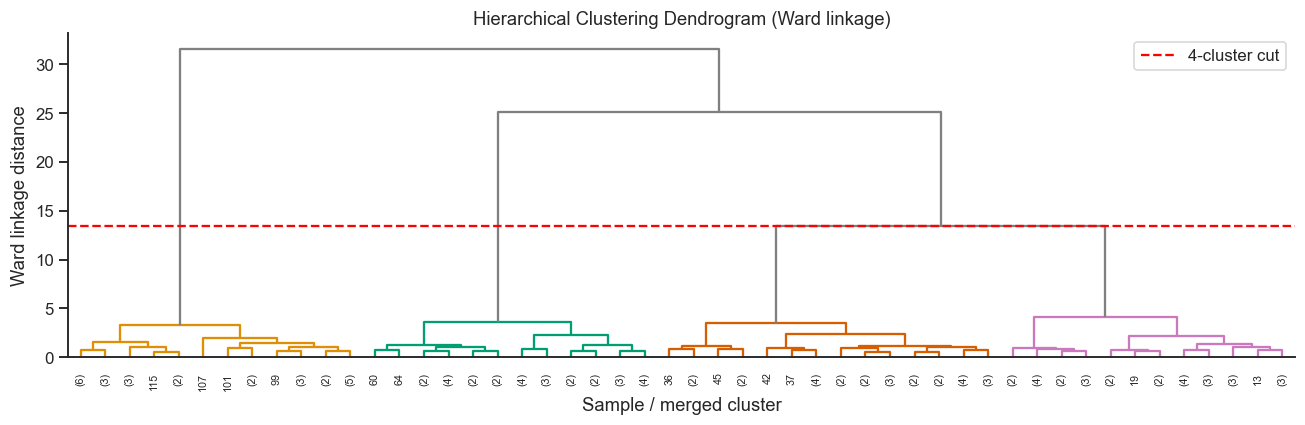

Hierarchical ARI (Ward, k=4) vs true grades: 1.000


In [5]:
# ── Dendrogram ───────────────────────────────────────────────────────────────
Z_link = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(12, 4))
color_threshold = Z_link[-3, 2]   # cut at 4 clusters
dendrogram(Z_link, ax=ax, truncate_mode='lastp', p=50,
           color_threshold=color_threshold, above_threshold_color='gray',
           leaf_rotation=90, leaf_font_size=7)
ax.axhline(color_threshold, color='red', ls='--', lw=1.5, label='4-cluster cut')
ax.set_xlabel('Sample / merged cluster')
ax.set_ylabel('Ward linkage distance')
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Extract flat cluster labels
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc.fit_predict(X)
ari_hc = adjusted_rand_score(grades, hc_labels)
print(f'Hierarchical ARI (Ward, k=4) vs true grades: {ari_hc:.3f}')


:::{admonition} Interpreting the Dendrogram
:class: tip

- Ward linkage reaches the same conclusion as K-Means (ARI = 1.000) using a completely different mechanism — no cluster centres, just repeated nearest-cluster merges. Agreement between two different algorithms is a much stronger signal than either result alone.
- The dendrogram's y-axis (linkage distance) shows *how well-separated* the merges are: the four grade clusters merge into each other only at a much larger distance than the merges within each grade — that large jump right before the red cut line is the visual signature of four genuinely distinct groups, not four arbitrary subdivisions of one blob.
- If the grades were not well separated, you would see many small, similar-sized jumps all the way up the tree instead of one dominant jump — there would be no natural place to draw the cut line.
:::

## 16.4 DBSCAN — Density-Based Clustering

DBSCAN groups points that are densely connected and marks low-density points as **noise (−1)**. It does not require specifying k in advance but requires two hyperparameters: `eps` (neighbourhood radius) and `min_samples`.

DBSCAN found 4 clusters, 0 noise points


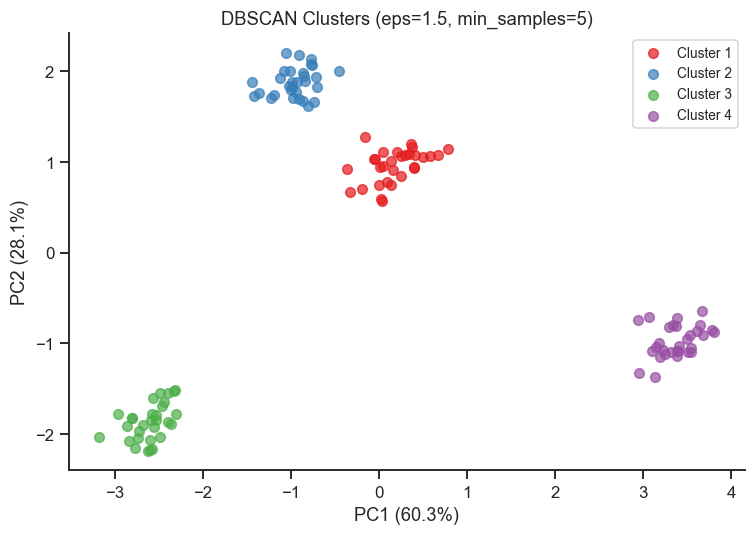

In [6]:
# ── DBSCAN on the 8-D XRF data ────────────────────────────────────────────────
db = DBSCAN(eps=1.5, min_samples=5)
db_labels = db.fit_predict(X)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = np.sum(db_labels == -1)
print(f'DBSCAN found {n_clusters_db} clusters, {n_noise_db} noise points')

fig, ax = plt.subplots(figsize=(7, 5))
unique_labels = sorted(set(db_labels))
palette = sns.color_palette('Set1', n_colors=max(n_clusters_db, 1))
for ki, lbl in enumerate(unique_labels):
    mask = db_labels == lbl
    color = 'lightgray' if lbl == -1 else palette[ki]
    name  = 'Noise' if lbl == -1 else f'Cluster {lbl+1}'
    ax.scatter(Z[mask,0], Z[mask,1], c=[color], label=name, s=40, alpha=0.7)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('DBSCAN Clusters (eps=1.5, min_samples=5)')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


:::{admonition} Interpreting the DBSCAN Result
:class: tip

- DBSCAN recovers exactly 4 clusters with 0 points labelled noise — it needed no `k` specified in advance, unlike K-Means and hierarchical clustering, yet still found the same structure.
- Zero noise points is a direct consequence of how the data were simulated: each grade forms a dense, roughly spherical blob in scaled feature space, so every point has enough close neighbours to satisfy `min_samples=5` within `eps=1.5`.
- On real XRF data, expect DBSCAN to flag some points as noise (label -1) — measurement outliers, mislabelled samples, or specimens genuinely intermediate between two grades. That noise label is useful information K-Means cannot give you: K-Means is forced to assign every point to some cluster, even genuine outliers.
- `eps` and `min_samples` are not free of assumptions either — too small an `eps` fragments true clusters into noise, too large merges distinct clusters together. Exercise 3 asks you to see this trade-off directly.
:::

## 16.5 t-SNE Visualisation

t-SNE (t-distributed Stochastic Neighbour Embedding) is a nonlinear dimensionality reduction technique that preserves **local neighbourhood structure**. It is used purely for 2-D visualisation — t-SNE coordinates are not meaningful for downstream regression.

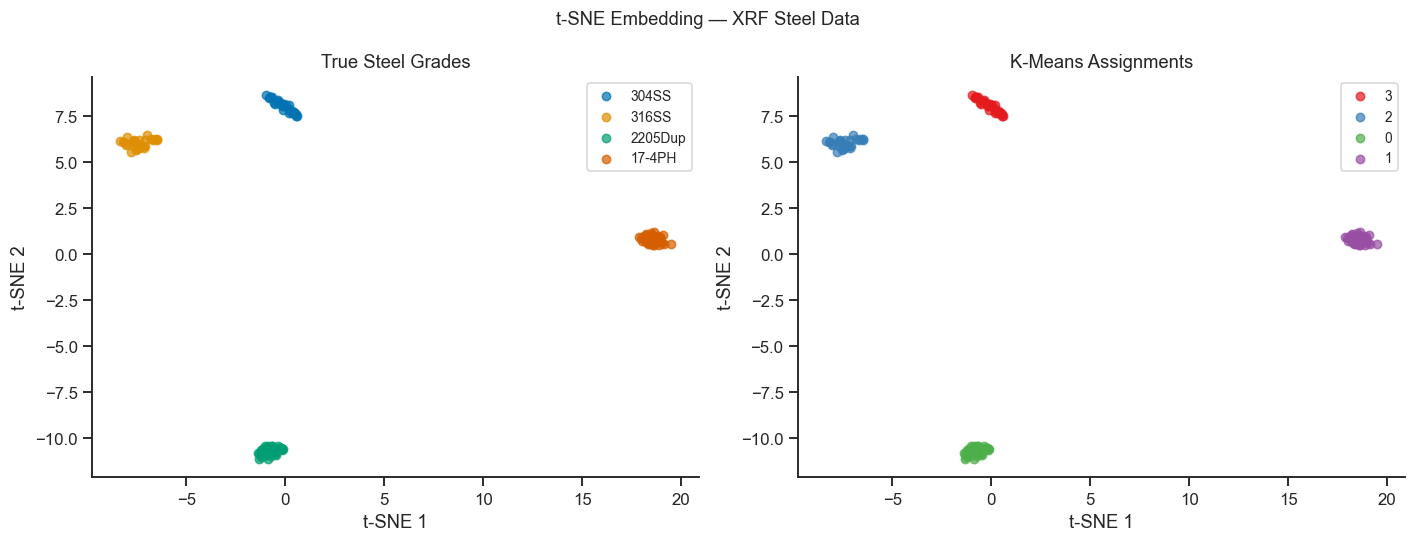

In [7]:
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
Z_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (labels, title, palette) in zip(
    axes,
    [(grades,     'True Steel Grades',       colors_grade),
     (km_labels,  'K-Means Assignments',     colors_km)]
):
    unique = list(dict.fromkeys(labels))
    for gi, lbl in enumerate(unique):
        mask = np.array(labels) == lbl
        ax.scatter(Z_tsne[mask,0], Z_tsne[mask,1],
                   c=[palette[gi]], label=str(lbl), s=30, alpha=0.7)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title(title)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('t-SNE Embedding — XRF Steel Data', fontsize=12)
plt.tight_layout()
plt.show()


## 16.6 UMAP Visualisation

UMAP (Uniform Manifold Approximation and Projection) provides a faster, often better-preserved global structure than t-SNE. The `n_neighbors` parameter controls the balance between local and global structure.

In [ ]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=1)
Z_umap = reducer.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (labels, title, palette) in zip(
    axes,
    [(grades,    'True Steel Grades',   colors_grade),
     (km_labels, 'K-Means Assignments', colors_km)]
):
    unique = list(dict.fromkeys(labels))
    for gi, lbl in enumerate(unique):
        mask = np.array(labels) == lbl
        ax.scatter(Z_umap[mask,0], Z_umap[mask,1],
                   c=[palette[gi]], label=str(lbl), s=30, alpha=0.7)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(title)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('UMAP Embedding — XRF Steel Data', fontsize=12)
plt.tight_layout()
plt.show()

:::{admonition} Interpreting t-SNE and UMAP
:class: tip

- Both t-SNE and UMAP separate the four grades into visually distinct islands, matching the K-Means clusters shown in the right panels of each figure — this is a *visual* confirmation of the same ARI = 1.000 result from Section 16.2, not new evidence on its own.
- Neither embedding's axes are interpretable in physical units (unlike PCA's loadings) — t-SNE 1/2 and UMAP 1/2 have no direct relationship to the original Cr, Ni, Mo, ... concentrations. Use PCA (Notebook 12, Part IV) when you need to know *which elements* drive the separation, and t-SNE/UMAP only to sanity-check that clusters look reasonable in 2-D.
- UMAP typically runs faster than t-SNE and better preserves distances *between* clusters (not just within), which is why the UMAP panels here show more consistent inter-cluster gaps than the t-SNE panels — a difference worth noticing even though both agree on the four groups.
- Because both are stochastic and sensitive to hyperparameters (`perplexity` for t-SNE, `n_neighbors`/`min_dist` for UMAP), always treat the *shapes* and *relative positions* of clusters with more scepticism than a quantitative metric like ARI — see Exercise 2.
:::

## 16.7 Method Comparison Summary

| Method | Requires k? | Handles noise? | Shape assumption | Interpretable axes? |
|---|---|---|---|---|
| K-Means | Yes | No | Spherical, equal size | No (use PCA for plotting) |
| Hierarchical (Ward) | Yes (cut) | No | Compact | No |
| DBSCAN | No | Yes (noise label) | Arbitrary shape, but roughly uniform density | No |
| t-SNE | N/A | N/A | None (visualisation only) | No |
| UMAP | N/A | N/A | None (visualisation only) | No |
| PCA (linear) | N/A | N/A | Linear | Yes (loadings) |
| LDA (supervised) | No (uses labels) | No | Gaussian within-class | Yes (discriminant coefficients) |

DBSCAN's "arbitrary shape" flexibility comes from a single global `eps`/
`min_samples` pair, which is exactly why it assumes clusters have *similar*
density to each other — it struggles when one true cluster is much denser
than another, since no single `eps` fits both well. HDBSCAN relaxes this by
letting density thresholds vary per cluster.

**Recommendation workflow:**
1. Start with **PCA** to understand linear structure.
2. Apply **K-Means** or **hierarchical clustering** to identify groups; validate with elbow/silhouette.
3. Use **t-SNE or UMAP** for visual quality checks — clusters that are visible here but not in PCA indicate nonlinear structure.
4. Apply **DBSCAN** when cluster shapes are irregular or when you want automatic noise rejection.


---
## Exercises

1. **Effect of scaling**: Re-run K-Means without `StandardScaler`. Does the ARI change significantly? Which elements dominate the un-scaled distance metric?

2. **Perplexity sensitivity**: Re-run t-SNE with `perplexity` = 5, 15, 50, and 100. How does the cluster separation change? What does perplexity control?

3. **DBSCAN parameter sweep**: Vary `eps` from 0.5 to 3.0 in steps of 0.25 (keeping `min_samples=5`). Plot the number of clusters and the noise fraction vs `eps`. What is the optimal range?

4. **UMAP supervised embedding**: UMAP can be used in supervised mode by passing `y=true_labels` to `fit_transform`. Compare the supervised and unsupervised UMAP embeddings. When would you use the supervised variant?
